# Data Preparation

In [1]:
import pandas as pd

In [2]:
df_titanic = pd.read_csv('titanic/train.csv')

In [3]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Missing Values

In [4]:
df_titanic_2 = df_titanic.drop(['Cabin'], axis = 1)

In [5]:
df_titanic_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [6]:
df_titanic_2[df_titanic_2.Embarked.isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [7]:
df_titanic_2.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [8]:
df_titanic_2[(df_titanic_2.Pclass == 1) & (df_titanic_2.Sex == 'female')].Embarked.value_counts()

Embarked
S    48
C    43
Q     1
Name: count, dtype: int64

In [9]:
df_titanic_3 = df_titanic_2[~df_titanic_2.Embarked.isna()]
df_titanic_3.shape

(889, 11)

In [10]:
df_titanic_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


<Axes: >

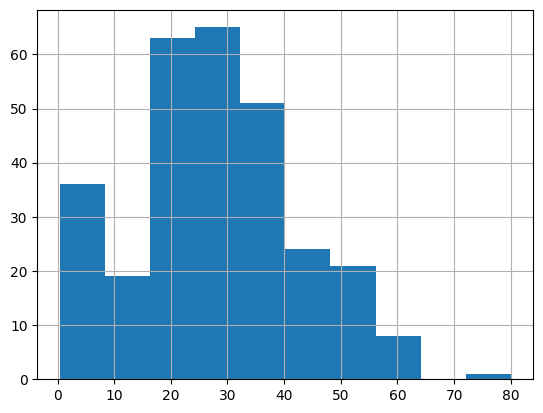

In [11]:
df_titanic_3[df_titanic_3.Survived==1].Age.hist()

<Axes: >

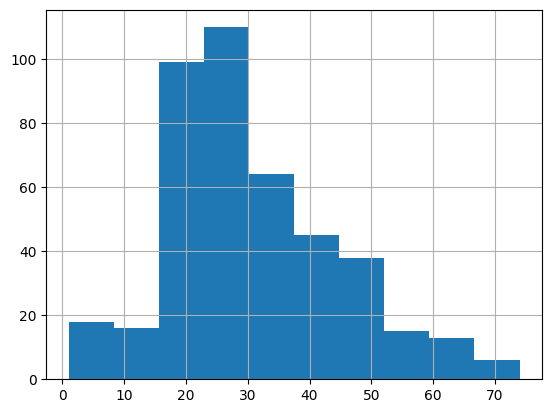

In [12]:
df_titanic_3[df_titanic_3.Survived==0].Age.hist()

In [13]:
df_titanic_3.Age.mean(), df_titanic_3.Age.median()

(29.64209269662921, 28.0)

In [14]:
temp = df_titanic_3.Age.median()
df_titanic_4 = df_titanic_3.copy()
df_titanic_4.Age = df_titanic_3.Age.fillna(temp)

In [15]:
df_titanic_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [16]:
import numpy as np
df_temp = pd.DataFrame({'x': [1, 2, 3, 4, np.nan, 6, np.nan, 8]})
df_temp

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,NaN
5,6.0
6,NaN
7,8.0


In [17]:
df_temp.ffill()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,4.0
5,6.0
6,6.0
7,8.0


In [18]:
df_temp.bfill()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,6.0
5,6.0
6,8.0
7,8.0


In [19]:
df_temp = pd.DataFrame({'x': [1, 2, 3, 4, np.nan, 6, np.nan, np.nan, 9]})
df_temp.ffill()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,4.0
5,6.0
6,6.0
7,6.0
8,9.0


In [20]:
df_temp = pd.DataFrame({'x': [1, 2, 3, 4, np.nan, 6, np.nan, np.nan]})
df_temp.ffill()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,4.0
5,6.0
6,6.0
7,6.0


In [21]:
df_temp = pd.DataFrame({'x': [1, 2, 3, 4, np.nan, 6, np.nan, np.nan]})
df_temp.bfill()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,6.0
5,6.0
6,NaN
7,NaN


In [22]:
df_temp = pd.DataFrame({'x': [1, 2, 3, 4, np.nan, 6, np.nan, 8]})
df_temp.interpolate()

,x
0,1.0
1,2.0
2,3.0
3,4.0
4,5.0
5,6.0
6,7.0
7,8.0


In [23]:
df_temp = pd.DataFrame({'x': [np.nan, 1, 2, 3, 4, np.nan, 6, np.nan, 8, np.nan]})
df_temp.interpolate()

,x
0,NaN
1,1.0
2,2.0
3,3.0
4,4.0
5,5.0
6,6.0
7,7.0
8,8.0
9,8.0


In [24]:
df_temp = pd.DataFrame({'x': [np.nan, 1, 2, 3, 4, np.nan, 6, np.nan, np.nan]})
df_temp.interpolate()

,x
0,NaN
1,1.0
2,2.0
3,3.0
4,4.0
5,5.0
6,6.0
7,6.0
8,6.0


In [25]:
df_temp = pd.DataFrame({'x': [1, 4, 9, 16, np.nan, 36, 49]})
df_temp.interpolate()

,x
0,1.0
1,4.0
2,9.0
3,16.0
4,26.0
5,36.0
6,49.0


In [26]:
df_temp = pd.DataFrame({'x': [1, 4, 9, 16, np.nan, 36, 49]})
df_temp.interpolate(method='polynomial', order=2)

,x
0,1.0
1,4.0
2,9.0
3,16.0
4,25.0
5,36.0
6,49.0


### Categorical Values

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df_titanic_4.Embarked)

LabelEncoder()

In [28]:
df_titanic_4.Embarked

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 889, dtype: object

In [29]:
le.transform(df_titanic_4.Embarked)

array([2, 0, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2,
       1, 2, 2, 2, 0, 2, 1, 2, 0, 0, 1, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0,
       1, 2, 1, 1, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       0, 2, 2, 0, 2, 1, 2, 0, 2, 2, 2, 0, 2, 2, 0, 1, 2, 0, 2, 0, 2, 2,
       2, 2, 0, 2, 2, 2, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 0, 2, 2,
       0, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 0, 1, 2, 1,
       2, 2, 2, 2, 0, 2, 2, 2, 0, 1, 0, 2, 2, 2, 2, 1, 0, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2,
       2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 0, 2,
       2, 2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 2, 0, 1, 1,

In [30]:
df_titanic_5 = df_titanic_4.copy()
le = LabelEncoder()
df_titanic_5.Embarked = le.fit_transform(df_titanic_4.Embarked) 

In [31]:
df_titanic_5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    int32  
dtypes: float64(2), int32(1), int64(5), object(3)
memory usage: 79.9+ KB


In [32]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
result = ohe.fit_transform(df_titanic_4[['Embarked']]) 
result

<889x3 sparse matrix of type '<class 'numpy.float64'>'
	with 889 stored elements in Compressed Sparse Row format>

In [33]:
df_titanic_4.shape

(889, 11)

In [34]:
pd.DataFrame.sparse.from_spmatrix(result)

,0,1,2
0,0,0,1.0
1,1.0,0,0
2,0,0,1.0
3,0,0,1.0
4,0,0,1.0
...,...,...,...
884,0,0,1.0
885,0,0,1.0
886,0,0,1.0
887,1.0,0,0


In [35]:
pd.get_dummies(df_titanic_4[['Embarked']])

,Embarked_C,Embarked_Q,Embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [36]:
pd.get_dummies(df_titanic_4['Embarked'])

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [37]:
pd.get_dummies(df_titanic_4['Embarked'], prefix='Embarked')

,Embarked_C,Embarked_Q,Embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


In [38]:
pd.get_dummies(df_titanic_4['Embarked'], prefix='Embarked', drop_first=True)

,Embarked_Q,Embarked_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True
...,...,...
886,False,True
887,False,True
888,False,True
889,False,False


### OrdinalEncoder

In [39]:
from sklearn.preprocessing import OrdinalEncoder
OrdinalEncoder(categories=[['Q', 'S', 'C']]).fit_transform(df_titanic_4[['Embarked']])[:10] 

array([[1.],
       [2.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [2.]])

### BinaryEncoder

In [40]:
from category_encoders import BinaryEncoder
BinaryEncoder().fit_transform(df_titanic_4[['Embarked']])[:10] 

,Embarked_0,Embarked_1
0,0,1
1,1,0
2,0,1
3,0,1
4,0,1
5,1,1
6,0,1
7,0,1
8,0,1
9,1,0


In [41]:
# 7 Categories
# 001
# 010
# 011
# 100
# 101
# 110
# 111

### Outliers

In [42]:
df_titanic_5.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681,1.535433
std,256.998173,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504,0.792088
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,224.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800,1.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,2.000000
75%,668.000000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,2.000000


<Axes: >

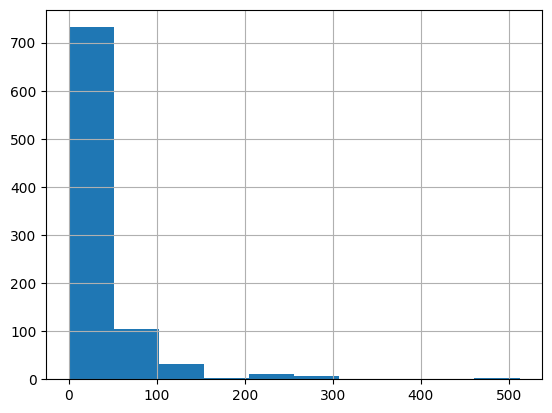

In [43]:
df_titanic_5.Fare.hist()

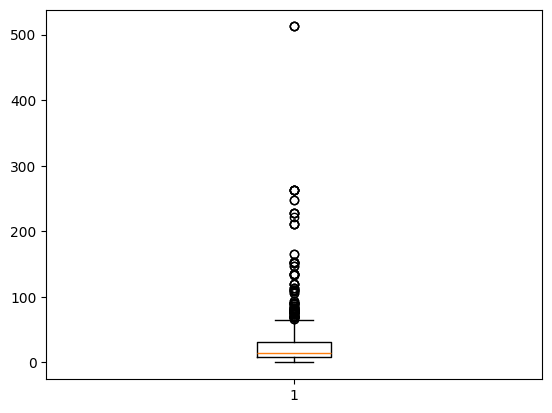

In [44]:
import matplotlib.pyplot as plt
plt.boxplot(df_titanic_5.Fare)
plt.show()

In [45]:
q1 = df_titanic_5.Fare.quantile(0.25)
q3 = df_titanic_5.Fare.quantile(0.75)
iqr = q3 - q1
print(iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr)

23.1042 -26.7605 65.6563


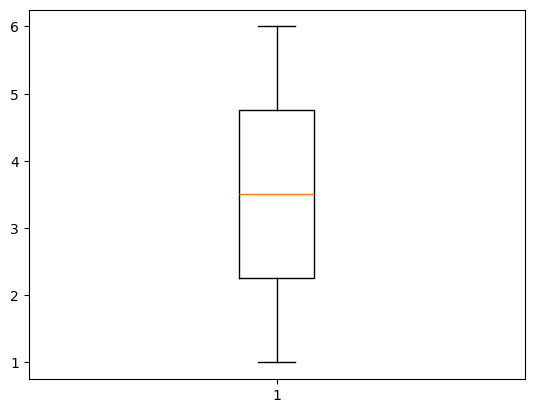

In [46]:
temp = np.array([1, 2, 3, 4, 5, 6])
plt.boxplot(temp)
plt.show()

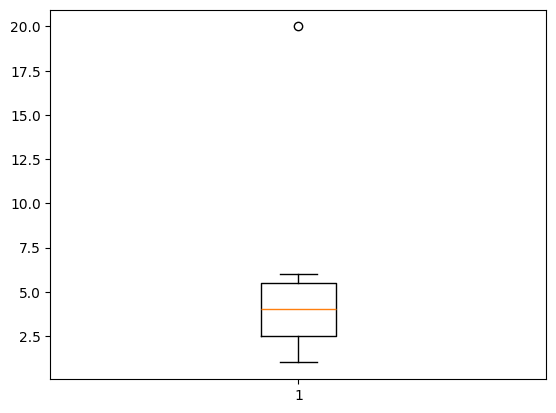

In [47]:
temp = np.array([1, 2, 3, 4, 5, 6, 20])
plt.boxplot(temp)
plt.show()

23.1042 -26.7605 65.6563


<Axes: >

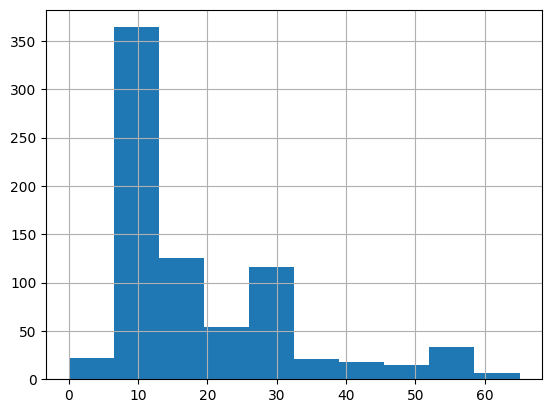

In [48]:
q1 = df_titanic_5.Fare.quantile(0.25)
q3 = df_titanic_5.Fare.quantile(0.75)
iqr = q3 - q1
print(iqr, q1 - 1.5 * iqr, q3 + 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr
df_titanic_5[df_titanic_5.Fare < upper_bound].Fare.hist()

In [49]:
df_temp = df_titanic_5.copy()
df_temp['z_score'] = (df_titanic_5.Fare - df_titanic_5.Fare.mean()) / df_titanic_5.Fare.std() 

<Axes: >

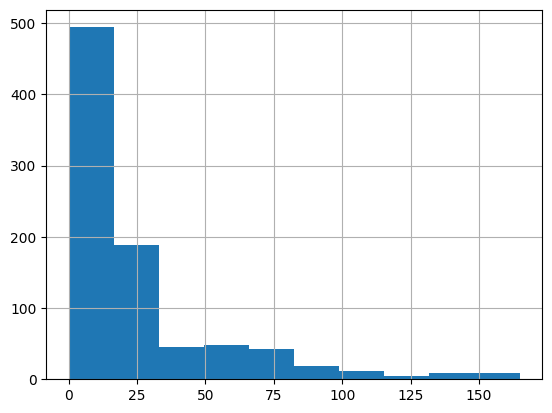

In [50]:
df_temp[(df_temp['z_score'] <= 3) & (df_temp['z_score'] >= -3)].Fare.hist()

<Axes: >

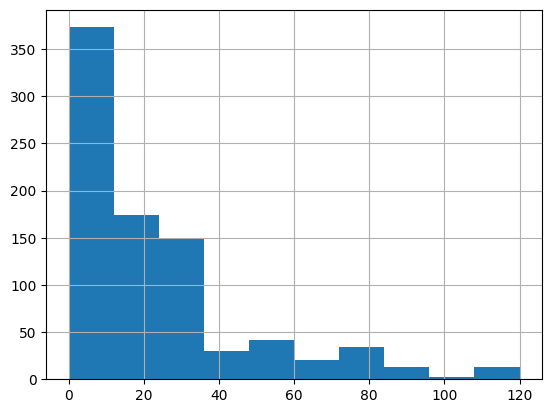

In [51]:
df_temp[(df_temp['z_score'] <= 2) & (df_temp['z_score'] >= -2)].Fare.hist()

In [52]:
from scipy.stats import zscore
zscore(df_titanic_5.Fare, ddof=True)[:3]

0   -0.499958
1    0.788503
2   -0.486376
Name: Fare, dtype: float64

In [53]:
df_temp['z_score'][:3]

0   -0.499958
1    0.788503
2   -0.486376
Name: z_score, dtype: float64

In [54]:
from sklearn.ensemble import IsolationForest
isof = IsolationForest(contamination=0.01)
temp = isof.fit_predict(df_titanic_5[['Fare']])
np.unique(temp, return_counts=True)

(array([-1,  1]), array([  7, 882], dtype=int64))

### Binning

<Axes: >

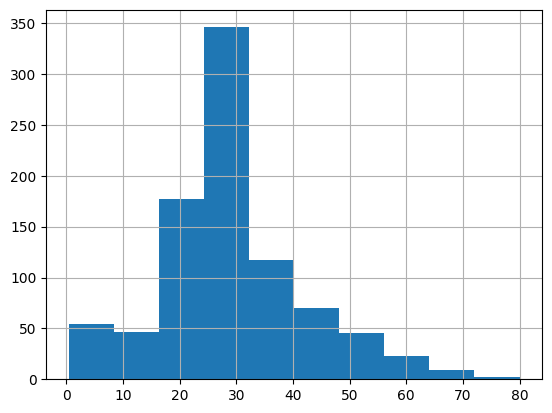

In [55]:
df_titanic_5.Age.hist()

In [56]:
from pprint import pprint
binned, bins = pd.cut(df_titanic_5.Age, 10, retbins=True)
centers = (bins[:-1] + bins[1:]) / 2
binned_centered = pd.cut(df_titanic_5.Age, bins=bins, labels=centers)
binned_centered

0      20.315
1      36.231
2      28.273
3      36.231
4      36.231
        ...  
886    28.273
887    20.315
888    28.273
889    28.273
890    28.273
Name: Age, Length: 889, dtype: category
Categories (10, float64): [4.35921 < 12.35700 < 20.31500 < 28.27300 ... 52.147 < 60.105 < 68.063 < 76.021]

In [57]:
bins

array([ 0.34042,  8.378  , 16.336  , 24.294  , 32.252  , 40.21   ,
       48.168  , 56.126  , 64.084  , 72.042  , 80.     ])

In [58]:
from pprint import pprint
binned, bins = pd.qcut(df_titanic_5.Age, 4, retbins=True)
centers = (bins[:-1] + bins[1:]) / 2
binned_centered = pd.cut(df_titanic_5.Age, bins=bins, labels=centers)
binned_centered

0      11.21
1      57.50
2      25.00
3      31.50
4      31.50
       ...  
886    25.00
887    11.21
888    25.00
889    25.00
890    31.50
Name: Age, Length: 889, dtype: category
Categories (4, float64): [11.21 < 25.00 < 31.50 < 57.50]

In [59]:
def changeAge(x):
    if x <= 2:
        return 1
    if x <= 6:
        return 4
    if x <= 10:
        return 8
    if x <= 20:
        return 15
    if x <= 40:
        return 40
    if x <= 60:
        return 50
    return 70

df_titanic_6 = df_titanic_5.copy()
df_titanic_6.Age = df_titanic_6.Age.apply(changeAge)
df_titanic_6.Age.value_counts()

Age
40    561
50    128
15    115
1      24
4      23
70     21
8      17
Name: count, dtype: int64

In [60]:
df_titanic_7 = df_titanic_5.copy()
bins = [0, 2, 6, 10, 20, 40, 60, 80]
labels = [1, 4, 8, 15, 40, 50, 70]
df_titanic_7.Age = pd.cut(df_titanic_5.Age, bins=bins, labels=labels)
df_titanic_7.Age.value_counts()

Age
40    561
50    128
15    115
1      24
4      23
70     21
8      17
Name: count, dtype: int64

In [61]:
df_titanic_6.groupby(['Age', 'Survived']).Survived.count()

Age  Survived
1    0             9
     1            15
4    0             5
     1            18
8    0            12
     1             5
15   0            71
     1            44
40   0           357
     1           204
50   0            78
     1            50
70   0            17
     1             4
Name: Survived, dtype: int64

In [62]:
df_titanic_5.groupby(['Age', 'Survived']).Survived.count()

Age    Survived
0.42   1           1
0.67   1           1
0.75   1           2
0.83   1           2
0.92   1           1
                  ..
70.00  0           2
70.50  0           1
71.00  0           2
74.00  0           1
80.00  1           1
Name: Survived, Length: 142, dtype: int64

### Scaling

In [63]:
from sklearn.preprocessing import MinMaxScaler
temp = (df_titanic_5.Age - df_titanic_5.Age.min()) / (df_titanic_5.Age.max() - df_titanic_5.Age.min())
print(temp.min(), temp.mean(), temp.max(), temp.std(), temp.median())
sc = MinMaxScaler()
temp = sc.fit_transform(df_titanic_5[['Age']])
print(temp.min(), temp.mean(), temp.max(), temp.std(), np.median(temp))


0.0 0.36309565036463937 1.0 0.16316828717882353 0.3465694898215632
0.0 0.36309565036463926 1.0 0.163076490666816 0.34656948982156316


In [64]:
from sklearn.preprocessing import StandardScaler
temp = (df_titanic_5.Age - df_titanic_5.Age.mean()) / (df_titanic_5.Age.std())
print(temp.min(), temp.mean(), temp.max(), temp.std(), temp.median())
sc = StandardScaler()
temp = sc.fit_transform(df_titanic_5[['Age']])
print(temp.min(), temp.mean(), temp.max(), temp.std(), np.median(temp))

-2.2252832130713385 2.7974123455122054e-16 3.9033586773963522 1.0 -0.10128291979289035
-2.2265358353000453 2.717486278497571e-16 3.905555896077194 0.9999999999999999 -0.10133993241760961


In [65]:
from sklearn.preprocessing import RobustScaler
temp = (df_titanic_5.Age - df_titanic_5.Age.median()) / (df_titanic_5.Age.quantile(0.75)-df_titanic_5.Age.quantile(0.25))
print(temp.min(), temp.mean(), temp.max(), temp.std(), temp.median())
sc = RobustScaler()
temp = sc.fit_transform(df_titanic_5[['Age']])
print(temp.min(), temp.mean(), temp.max(), temp.std(), np.median(temp))

-2.1215384615384614 0.10116552738599982 4.0 0.9988409456685212 0.0
-2.1215384615384614 0.10116552738599982 4.0 0.9982790097896322 0.0


-0.6480576784030068 -1.1961998918520205e-17 9.661740104981664 1.0 -0.3571902456652305
-0.6484216535389205 3.987332972840069e-18 9.667166525013505 1.0 -0.3573908580066095


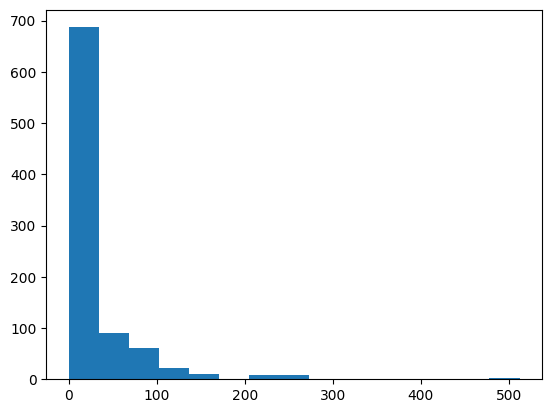

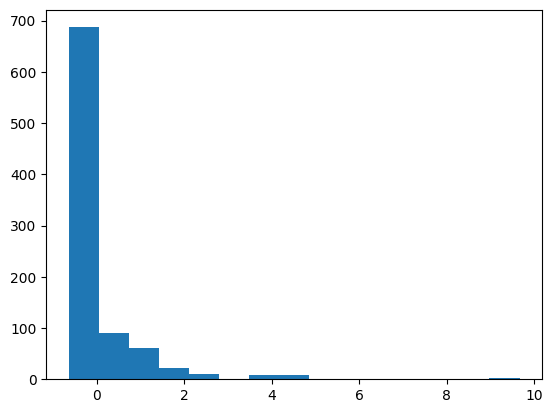

-0.37675070960209955 1.387921339279509 1.9030899869919435 0.3407623026559205 1.4471580313422192


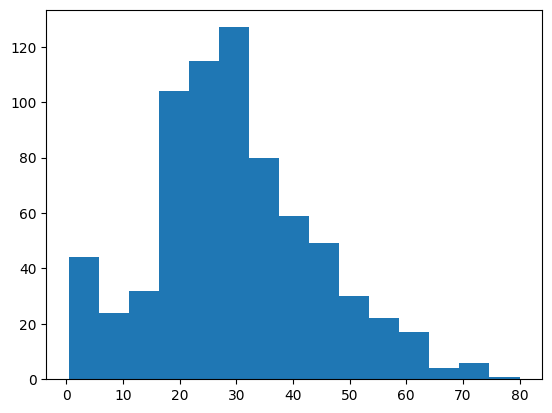

In [66]:
temp = (df_titanic.Fare - df_titanic.Fare.mean()) / (df_titanic.Fare.std())
print(temp.min(), temp.mean(), temp.max(), temp.std(), temp.median())
sc = StandardScaler()
temp = sc.fit_transform(df_titanic[['Fare']])
print(temp.min(), temp.mean(), temp.max(), temp.std(), np.median(temp))
plt.hist(df_titanic.Fare, bins=15)
plt.show()
plt.hist(temp, bins=15)
plt.show()
temp = np.log10(df_titanic.Age)
print(temp.min(), temp.mean(), temp.max(), temp.std(), temp.median())
plt.hist(df_titanic.Age, bins=15)
plt.show()

# Feature Selection

### Variance

In [67]:
from sklearn.datasets import make_classification
X, y = make_classification(1000, n_features=10, n_informative=10, n_redundant=0, random_state=42)
X.shape

(1000, 10)

In [68]:
X.var(axis=0)

array([4.0367044 , 4.72351903, 4.76978097, 4.38518767, 3.7075285 ,
       4.53389621, 4.42253228, 4.04015099, 3.52953267, 4.20203979])

In [69]:
X[:, 2]=10
X[:, 4] /= 100

In [70]:
X.var(axis=0)

array([4.03670440e+00, 4.72351903e+00, 0.00000000e+00, 4.38518767e+00,
       3.70752850e-04, 4.53389621e+00, 4.42253228e+00, 4.04015099e+00,
       3.52953267e+00, 4.20203979e+00])

In [71]:
from sklearn.feature_selection import VarianceThreshold
X_new = VarianceThreshold(0.01).fit_transform(X)
print(X_new.shape)
X_new.var(axis=0)

(1000, 8)


array([4.0367044 , 4.72351903, 4.38518767, 4.53389621, 4.42253228,
       4.04015099, 3.52953267, 4.20203979])

In [72]:
from sklearn.preprocessing import MinMaxScaler
MinMaxScaler().fit_transform(X).var(axis=0)

array([0.02113342, 0.02183724, 0.        , 0.01881114, 0.02124466,
       0.02350957, 0.02174524, 0.02384341, 0.02047183, 0.02204237])

In [73]:
from sklearn.preprocessing import StandardScaler
StandardScaler().fit_transform(X).var(axis=0)

array([1., 1., 0., 1., 1., 1., 1., 1., 1., 1.])

### Wrapper Methods

In [74]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

1.0
0.9202127659574468


In [75]:
from sklearn.feature_selection import SequentialFeatureSelector
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
fs = SequentialFeatureSelector(model)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

(381, 30)
1.0
0.9202127659574468
(381, 15)
1.0
0.9361702127659575


In [76]:
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
fs = SequentialFeatureSelector(model, direction='backward')
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

(381, 30)
1.0
0.9202127659574468
(381, 15)
1.0
0.9042553191489362


In [77]:
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
fs = SequentialFeatureSelector(model, direction='backward', n_features_to_select=10)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

(381, 30)
1.0
0.9202127659574468
(381, 10)
1.0
0.9095744680851063


In [78]:
from sklearn.feature_selection import RFE
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(model.feature_importances_)
fs = RFE(model)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(model.feature_importances_)

(381, 30)
1.0
0.9202127659574468
[0.         0.0429321  0.00742256 0.         0.         0.
 0.         0.72319377 0.00890707 0.         0.         0.
 0.         0.01403804 0.00262909 0.         0.00742256 0.
 0.         0.01088333 0.03335843 0.01896754 0.05998501 0.
 0.02108309 0.         0.0491774  0.         0.         0.        ]
(381, 15)
1.0
0.9148936170212766
[0.73061633 0.         0.01403804 0.         0.00742256 0.
 0.00262909 0.01088333 0.03698536 0.05942546 0.05635808 0.
 0.01978414 0.         0.06185761]


In [79]:
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(model.feature_importances_)
fs = RFE(model, n_features_to_select=10)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(model.feature_importances_)

(381, 30)
1.0
0.9202127659574468
[0.         0.0429321  0.00742256 0.         0.         0.
 0.         0.72319377 0.00890707 0.         0.         0.
 0.         0.01403804 0.00262909 0.         0.00742256 0.
 0.         0.01088333 0.03335843 0.01896754 0.05998501 0.
 0.02108309 0.         0.0491774  0.         0.         0.        ]
(381, 10)
1.0
0.9148936170212766
[0.72319377 0.00742256 0.01403804 0.0123712  0.01830589 0.04533574
 0.06292024 0.05635808 0.01087707 0.0491774 ]


In [80]:
from sklearn.neighbors import KNeighborsClassifier
cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(X_train.shape)
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
fs = RFE(model, n_features_to_select=10)
X_train = fs.fit_transform(X_train, y_train)
X_test = fs.transform(X_test)
print(X_train.shape)
model.fit(X_train, y_train)
y_pred = model.predict(X_train)
print(accuracy_score(y_train, y_pred))
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

(381, 30)
0.9212598425196851
0.9521276595744681


ValueError: when `importance_getter=='auto'`, the underlying estimator KNeighborsClassifier should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.

### PCA

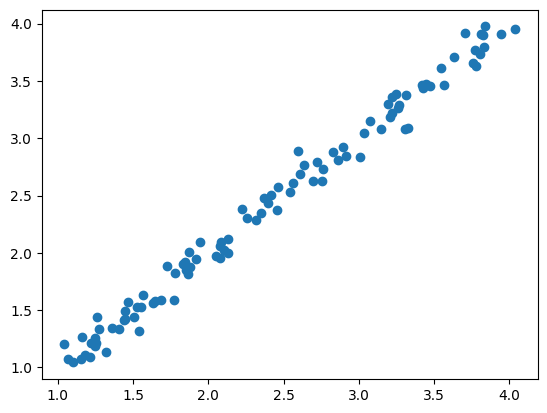

In [81]:
np.random.seed(42)
X = 3 * np.random.rand(100) + 1
df = pd.DataFrame({'x1': X + np.random.randn(100) / 10, 'x2': X + np.random.randn(100) / 30})
plt.scatter(df['x1'], df['x2'])
plt.show()

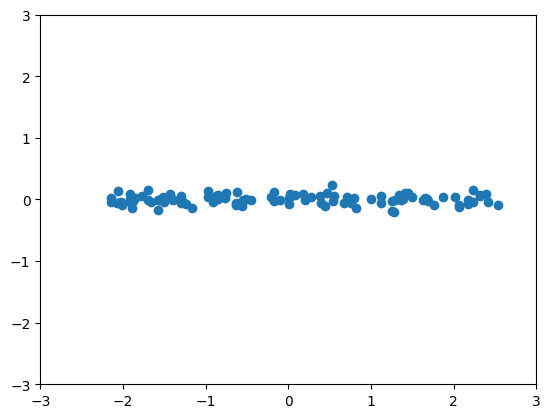

In [82]:
sc = StandardScaler()
df_2 = pd.DataFrame(sc.fit_transform(df), columns=df.columns)
w, v = np.linalg.eig(np.cov(df_2, rowvar=False, bias=True))
df_3=df_2@v
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.scatter(df_3[0], df_3[1])
plt.show()

In [83]:
df_3.head()

,0,1
0,-0.452618,-0.005164
1,2.320159,0.048679
2,1.256175,-0.022468
3,0.528044,0.227523
4,-1.509948,0.041602


In [84]:
df_3.var(axis=0)

0    2.013978
1    0.006224
dtype: float64

In [85]:
from sklearn.decomposition import PCA
pca = PCA(1)
pca.fit_transform(df_2)[:5]

array([[-0.45261811],
       [ 2.32015899],
       [ 1.25617485],
       [ 0.52804367],
       [-1.50994777]])

### TSNE

(1797, 64)
(1797, 2)


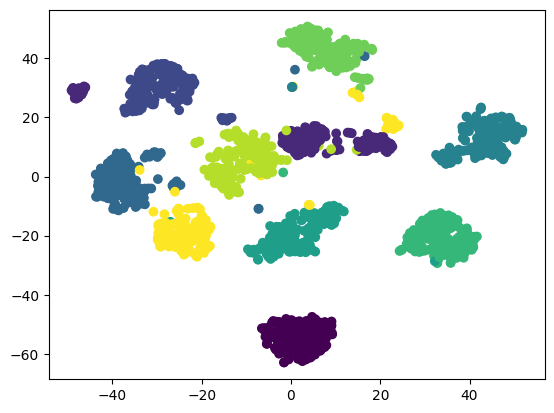

In [86]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
X = load_digits().data
y = load_digits().target
tsne = TSNE(2, random_state=42)
print(X.shape)
X_new = tsne.fit_transform(X)
print(X_new.shape)
plt.scatter(X_new[:, 0], X_new[:, 1], c=y)
plt.show()

In [87]:
# PowerTransformer